In [1]:
import os, sys
import torch
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("")), 'src'))



Source shape: torch.Size([3, 512, 512])
Target shape: torch.Size([3, 512, 512])


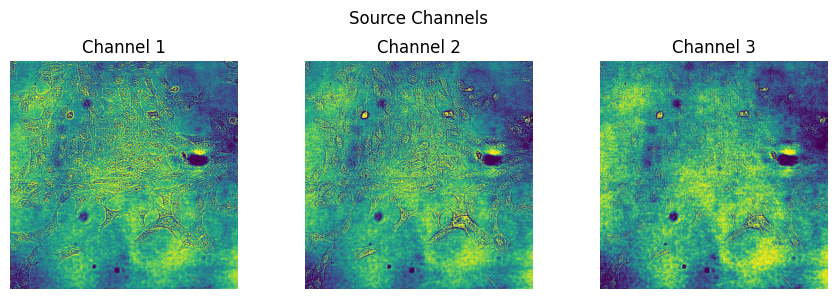

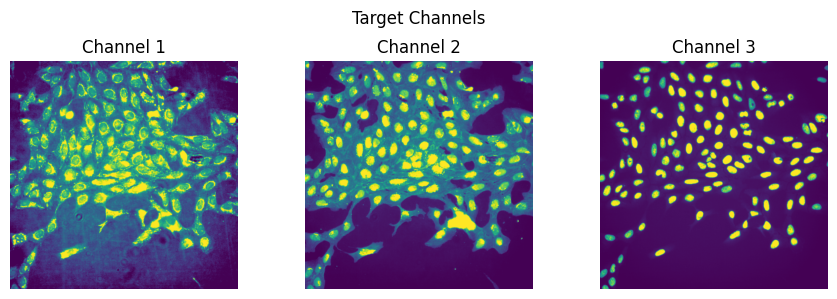

In [2]:

from data_loader import DiffusionDataset, get_diffusion_dataloader, visualize_image_channels

# 1) Point to the CSV that lists your partial paths for the dummy data:
csv_list = [os.path.join('..', "tests", "sdfsd_dummy data.csv")]

# 2) Create the dataset (channels 1–3 as “source”, 4–6 as “target”):
dataset = DiffusionDataset(
    csv_file_list=csv_list,
    images_dir=os.path.join('..', "tests",),
    source_channels=[6, 7, 8],
    target_channels=[1, 2, 5],
    img_size=(512,512)
)

# 3) Pull out one sample:
src_tensor, tgt_tensor = dataset[0]
print("Source shape:", src_tensor.shape)   # e.g. (3, 512, 512)
print("Target shape:", tgt_tensor.shape)   # e.g. (3, 512, 512)

# 4) Visualize if you like:
visualize_image_channels(src_tensor, title="Source Channels")
visualize_image_channels(tgt_tensor, title="Target Channels")


In [3]:
from PIL import Image
import torch
import torchvision.transforms as transforms
from torchvision.utils import save_image
from diffusers import AutoencoderDC

device = torch.device("cuda")
dc_ae: AutoencoderDC = AutoencoderDC.from_pretrained(f"mit-han-lab/dc-ae-f64c128-in-1.0-diffusers", torch_dtype=torch.float32).to(device).eval()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5),
])

image = tgt_tensor.permute(1, 2, 0).cpu().numpy()
x = transform(image)[None].to(device)
latent = dc_ae.encode(x).latent
print(latent.shape)
y = dc_ae.decode(latent).sample
print(y.shape)

torch.Size([1, 128, 8, 8])
torch.Size([1, 3, 512, 512])


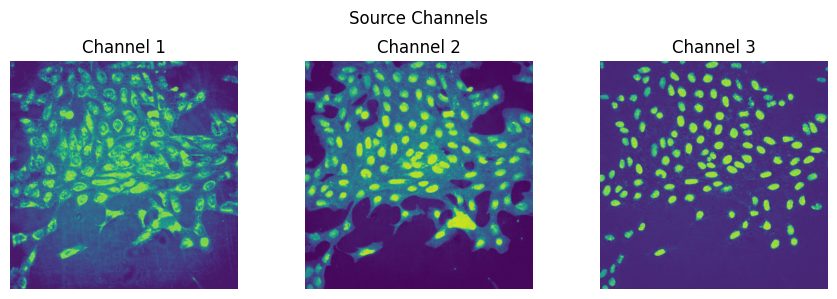

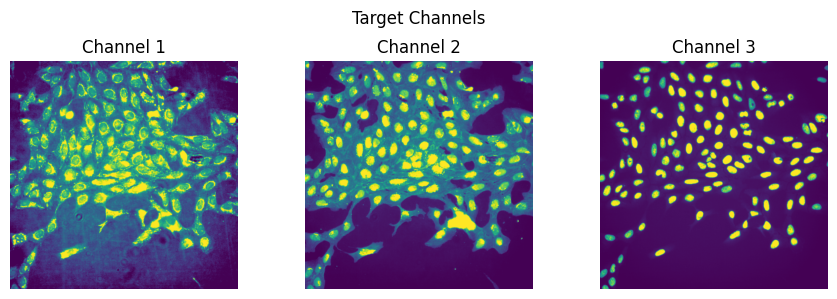

In [4]:
visualize_image_channels(y.squeeze(0), title="Source Channels")
visualize_image_channels(x.squeeze(0), title="Target Channels")

In [9]:
(max(x.max(), y.max()) - min(x.min(), y.min())).cpu().detach().numpy()

array(2.73145, dtype=float32)

In [10]:
# visualize_image_channels(y.squeeze(0), title="Source Channels")
# visualize_image_channels(tgt_tensor, title="Target Channels")


from skimage.metrics import structural_similarity as ssim
import cv2


original_image = x.squeeze(0).cpu().detach().numpy().transpose(1, 2, 0)
vae_image = y.squeeze(0).cpu().detach().numpy().transpose(1, 2, 0)

ssim = ssim(original_image, vae_image,full=True, channel_axis  = 2, data_range = (max(x.max(), y.max()) - min(x.min(), y.min())).cpu().detach().numpy())

print(ssim)

(np.float32(0.68425673), array([[[ 0.4557515 ,  0.14197628,  0.9324407 ],
        [ 0.59704196,  0.19146548,  0.9329265 ],
        [ 0.497848  ,  0.30057597,  0.9317723 ],
        ...,
        [ 0.23940228,  0.6707993 ,  0.94153863],
        [ 0.25181356,  0.6433411 ,  0.9430061 ],
        [ 0.29502374,  0.5958462 ,  0.9334158 ]],

       [[ 0.3915665 ,  0.23472671,  0.9276934 ],
        [ 0.5302445 ,  0.25248894,  0.923519  ],
        [ 0.5197095 ,  0.32198298,  0.92530626],
        ...,
        [ 0.27044755,  0.6967577 ,  0.95034885],
        [ 0.2896248 ,  0.67322135,  0.9514207 ],
        [ 0.35698605,  0.6281606 ,  0.9419128 ]],

       [[ 0.37091318,  0.31816623,  0.8964413 ],
        [ 0.53776324,  0.34482786,  0.8652131 ],
        [ 0.5556243 ,  0.4022613 ,  0.85885745],
        ...,
        [ 0.3318724 ,  0.6981954 ,  0.9587714 ],
        [ 0.34158027,  0.6675028 ,  0.96020645],
        [ 0.4007675 ,  0.6185348 ,  0.9519673 ]],

       ...,

       [[-0.26572245,  0.8908888 , 

In [ ]:


source_channels = [6, 7, 8]
target_channels = [1, 2, 5]
num_workers = min(os.cpu_count() - 2, os.cpu_count() // 2)


# 1) Point to the CSV that lists your partial paths for the dummy data:
train_plates = ["BR00116991", "BR00116992", "BR00116995", "BR00117024"]
valid_plates = ["BR00116993", "BR00117025"]
test_plates = ["BR00116994", "BR00117026", "BR00118041", "BR00118045"]

train_plates = [os.path.join("/home/ym429/rds/hpc-work/dissertation", f"unique_paths_{csv_file}.csv") for csv_file in train_plates]
valid_plates = [os.path.join("/home/ym429/rds/hpc-work/dissertation", f"unique_paths_{csv_file}.csv") for csv_file in valid_plates]
test_plates  = [os.path.join("/home/ym429/rds/hpc-work/dissertation", f"unique_paths_{csv_file}.csv") for csv_file in test_plates]

train_dataset = DiffusionDataset(csv_file_list=train_plates, source_channels=source_channels, target_channels=target_channels, img_size=(512,512))
valid_dataset = DiffusionDataset(csv_file_list=valid_plates, source_channels=source_channels, target_channels=target_channels, img_size=(512,512))
test_dataset = DiffusionDataset(csv_file_list=test_plates, source_channels=source_channels, target_channels=target_channels, img_size=(512,512))

# data loader
train_loader = get_diffusion_dataloader(train_dataset, batch_size=2, num_workers=num_workers, shuffle=True)
valid_loader = get_diffusion_dataloader(valid_dataset, batch_size=2, num_workers=num_workers, shuffle=False)
test_loader = get_diffusion_dataloader(test_dataset, batch_size=2, num_workers=num_workers, shuffle=False)

# 3) Pull out one sample:
src_tensor, tgt_tensor = train_dataset[0]
print("Source shape:", src_tensor.shape)   # e.g. (3, 512, 512)
print("Target shape:", tgt_tensor.shape)   # e.g. (3, 512, 512)

# 4) Visualize if you like:
visualize_image_channels(src_tensor, title="Source Channels")
visualize_image_channels(tgt_tensor, title="Target Channels")

# config = CFG(kappa=2.0, p=0.5, eta_T=0.999, T=50)
# scheduler = DiffusionScheduler(config)
# result = scheduler.get_noisy_image(20, src_tensor, tgt_tensor)
# visualize_image_channels(result)




In [3]:
import sys, os
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("")), 'src'))
from noise_scheduling import CFG, DiffusionScheduler
config = CFG(kappa=2.0, p=0.3, eta_T=0.999, T=15)
scheduler = DiffusionScheduler(config)

print(
    [
        scheduler.get_loss_coef(i + 1) for i in range(15)
    ]
)

# print(
#     [
#         scheduler.get_eta_t(i + 1) for i in range(15)
#     ]
# )
# print(
#     'alpha_t',
#     [
#         scheduler.get_alpha_t(i + 1) for i in range(15)
#     ]
# )

# print(
#     ((2 - 1) /( 50 - 1))**0.5 * (50 - 1)
# )

print(
    [
        config.kappa ** 2 * scheduler.get_eta_t(i) / scheduler.get_eta_t(i + 1) * scheduler.get_alpha_t(i + 1)
        for i in range(15)
    ]
)



print(
    [
        scheduler.get_eta_t(i) / scheduler.get_eta_t(i + 1)
        for i in range(15)
    ]
)

print(
    [
        scheduler.get_alpha_t(i + 1) / scheduler.get_eta_t(i + 1)
        for i in range(15)
    ]
)

print(
    [
        scheduler.get_alpha_t(i + 1)
        for i in range(15)
    ]
)

scheduler.get_alpha_t(1),scheduler.get_eta_t(1), scheduler.get_eta_t(config.T)

[tensor(312.5000), tensor(303.4727), tensor(5.0484), tensor(1.7161), tensor(0.8116), tensor(0.4507), tensor(0.2761), tensor(0.1808), tensor(0.1243), tensor(0.0887), tensor(0.0653), tensor(0.0492), tensor(0.0378), tensor(0.0296), tensor(0.0235)]
[tensor(0.0016), tensor(0.0016), tensor(0.0310), tensor(0.0542), tensor(0.0793), tensor(0.1070), tensor(0.1379), tensor(0.1723), tensor(0.2104), tensor(0.2525), tensor(0.2988), tensor(0.3497), tensor(0.4052), tensor(0.4658), tensor(0.5317)]
[tensor(1.), tensor(0.0289), tensor(0.4408), tensor(0.5687), tensor(0.6413), tensor(0.6894), tensor(0.7240), tensor(0.7504), tensor(0.7713), tensor(0.7883), tensor(0.8025), tensor(0.8145), tensor(0.8249), tensor(0.8340), tensor(0.8420)]
[tensor(1.), tensor(0.9711), tensor(0.5592), tensor(0.4313), tensor(0.3587), tensor(0.3106), tensor(0.2760), tensor(0.2496), tensor(0.2287), tensor(0.2117), tensor(0.1975), tensor(0.1855), tensor(0.1751), tensor(0.1660), tensor(0.1580)]
[tensor(0.0004), tensor(0.0134), tensor(

(tensor(0.0004), tensor(0.0004), tensor(0.9990))

In [2]:
import torch
import os, sys

sys.path.append(os.path.join(os.path.dirname(os.path.abspath("")), 'models'))
from unet import UNetModelSwin


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


c:\Users\yuche\OneDrive\Documents\Brain in a vat\CAM Mphil\DIS_final_project\venv\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
swin_unet_model = UNetModelSwin(image_size=256, 
              in_channels=3, model_channels=128, out_channels=3, 
              num_res_blocks=2, attention_resolutions=(128, 64), cond_lq = False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

swin_unet_model.to(device)

image = torch.randn(2, 3, 256, 256).to(device)
timesteps = torch.randint(0, 50, (2,)).to(device)

result = swin_unet_model(image, timesteps)


c:\Users\yuche\OneDrive\Documents\Brain in a vat\CAM Mphil\DIS_final_project\venv\Lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [5]:
image.shape, timesteps.shape

(torch.Size([2, 3, 256, 256]), torch.Size([2]))

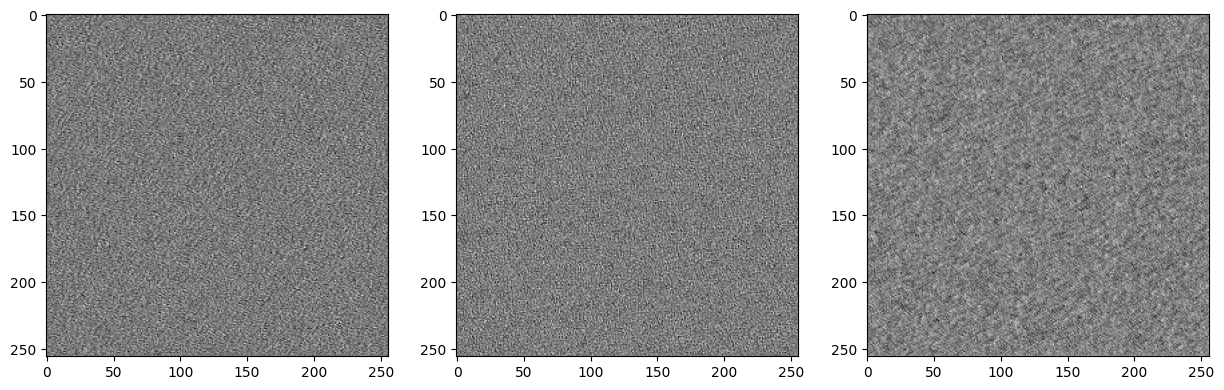

In [4]:
result = result.cpu().detach()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(result[0, 0, :, :], cmap="gray")
ax[1].imshow(result[0, 1, :, :], cmap="gray")
ax[2].imshow(result[0, 2, :, :], cmap="gray")

plt.show()
